<a href="https://colab.research.google.com/github/biopharma26/PracticeNotebooks/blob/main/5_4_GWAS_BigData_Cloud_Workflows.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experimental Session 4 — GWAS, Big Data, Cloud Computing and Workflow Management

### Aim
Perform a teaching-scale GWAS-style association analysis, demonstrate scalable tabular processing, create cloud-ready data paths, and build a simple workflow structure.

### Practical note
A full population GWAS normally uses genotype formats such as VCF/PLINK and tools such as PLINK, bcftools, Hail, or specialized GWAS software. This Colab experiment uses synthetic genotype data so that students can execute the complete statistical concept without downloading large cohorts.

### Learning outcomes
- Understand genotype encoding and allele frequency.
- Perform case/control association testing.
- Correct for multiple testing.
- Visualize Manhattan-like and QQ plots.
- Handle large tables in chunks.
- Understand cloud object storage and workflow concepts.

In [1]:
!pip -q install pandas numpy scipy matplotlib seaborn psutil

import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from scipy.stats import chi2_contingency
from statsmodels.stats.multitest import multipletests
import psutil, os, time

np.random.seed(2026)
print("RAM available (GB):", round(psutil.virtual_memory().available/1e9,2))

RAM available (GB): 12.3


## 1. Generate synthetic GWAS genotype data

Genotypes are encoded as 0, 1, 2 copies of the effect allele. A small subset of variants is simulated to have stronger association with the phenotype.

In [2]:
n = 1200
m = 5000

phenotype = np.random.binomial(1, .5, n)

# allele frequencies
maf = np.random.uniform(.05, .5, m)
G = np.zeros((n,m), dtype=np.int8)

for j, p in enumerate(maf):
    G[:,j] = np.random.binomial(2, p, n)

# Inject association into 12 variants
causal = np.arange(12)
for j in causal:
    risk = np.clip(.5 + .18*phenotype, .05, .95)
    G[:,j] = np.random.binomial(2, risk, n)

geno = pd.DataFrame(G, columns=[f"rs{j+1:06d}" for j in range(m)])
print("Genotype matrix:", geno.shape)
print("Cases:", phenotype.sum(), "Controls:", (1-phenotype).sum())

Genotype matrix: (1200, 5000)
Cases: 623 Controls: 577


## 2. Calculate allele frequency and perform chi-square association tests

For each variant, compare genotype counts between cases and controls.

In [4]:
cases = phenotype == 1
controls = phenotype == 0

pvals = []
mafs_observed = []

for snp in geno.columns:
    g = geno[snp].values
    case_counts = np.bincount(g[cases], minlength=3)
    control_counts = np.bincount(g[controls], minlength=3)

    table = np.array([case_counts, control_counts])

    # Identify columns (genotypes) that have at least one observation across cases and controls
    non_zero_cols = table.sum(axis=0) > 0
    filtered_table = table[:, non_zero_cols]

    # Check if the filtered table is valid for chi-square (at least 2x2 for a meaningful test)
    if filtered_table.shape[0] < 2 or filtered_table.shape[1] < 2:
        # Assign a non-significant p-value if the test cannot be performed meaningfully
        p = 1.0
    else:
        _, p, _, _ = chi2_contingency(filtered_table)
    pvals.append(p)
    mafs_observed.append(g.mean()/2)

gwas = pd.DataFrame({
    "SNP": geno.columns,
    "MAF": mafs_observed,
    "P": pvals
})

gwas["FDR"] = multipletests(gwas["P"], method="fdr_bh")[1]
gwas = gwas.sort_values("P")

display(gwas.head(20))

,SNP,MAF,P,FDR
8,rs000009,0.587500,9.524058e-27,4.762029e-23
2,rs000003,0.598750,9.076040e-26,2.269010e-22
10,rs000011,0.596250,6.474678e-21,1.079113e-17
6,rs000007,0.599167,3.582394e-20,4.477992e-17
1,rs000002,0.597917,6.253725e-19,6.253725e-16
7,rs000008,0.588750,8.127661e-19,6.664837e-16
0,rs000001,0.601667,9.330772e-19,6.664837e-16
3,rs000004,0.577917,2.362052e-16,1.476283e-13
4,rs000005,0.602917,4.042859e-15,2.246033e-12
5,rs000006,0.595833,1.483391e-14,7.416953e-12


## 3. Manhattan-style plot

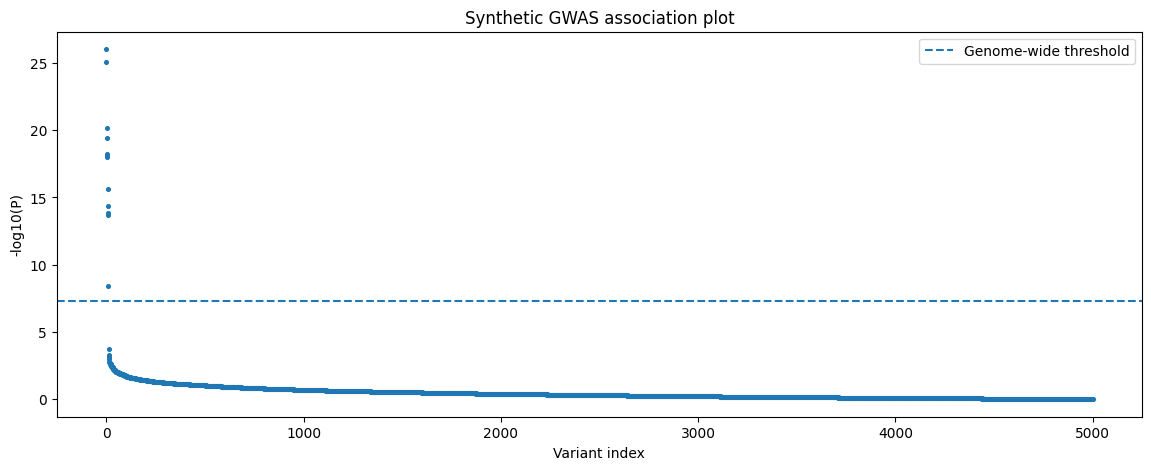

In [5]:
gwas = gwas.reset_index(drop=True)
gwas["Index"] = np.arange(len(gwas))

plt.figure(figsize=(14,5))
plt.scatter(gwas["Index"], -np.log10(gwas["P"]), s=7)
plt.axhline(-np.log10(5e-8), linestyle="--", label="Genome-wide threshold")
plt.xlabel("Variant index")
plt.ylabel("-log10(P)")
plt.title("Synthetic GWAS association plot")
plt.legend()
plt.show()

## 4. QQ plot

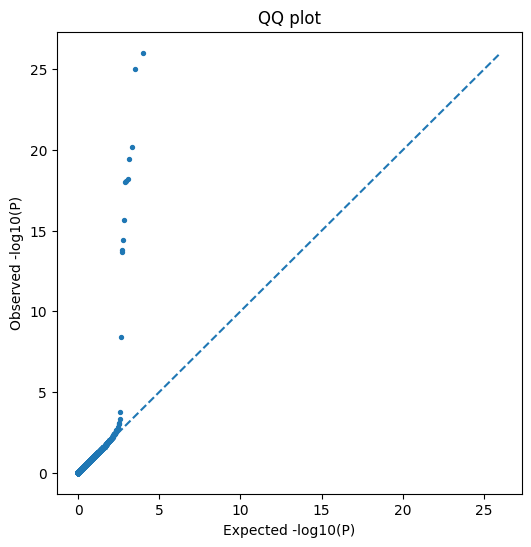

In [6]:
observed = -np.log10(np.sort(gwas["P"].values))
expected = -np.log10((np.arange(1,len(gwas)+1)-0.5)/len(gwas))

plt.figure(figsize=(6,6))
plt.scatter(expected, observed, s=8)
mx = max(expected.max(), observed.max())
plt.plot([0,mx],[0,mx], linestyle="--")
plt.xlabel("Expected -log10(P)")
plt.ylabel("Observed -log10(P)")
plt.title("QQ plot")
plt.show()

## 5. Multiple-testing interpretation

A genome-wide threshold such as 5×10⁻⁸ is conventional in many human GWAS contexts, but the correct threshold depends on study design, ancestry, LD structure, number of tests, and analysis framework.

In [7]:
hits = gwas[gwas["P"] < 5e-8]
fdr_hits = gwas[gwas["FDR"] < 0.05]

print("Nominal genome-wide threshold hits:", len(hits))
print("FDR < 0.05 hits:", len(fdr_hits))
display(hits.head(20))

Nominal genome-wide threshold hits: 12
FDR < 0.05 hits: 12


,SNP,MAF,P,FDR,Index
0,rs000009,0.587500,9.524058e-27,4.762029e-23,0
1,rs000003,0.598750,9.076040e-26,2.269010e-22,1
2,rs000011,0.596250,6.474678e-21,1.079113e-17,2
3,rs000007,0.599167,3.582394e-20,4.477992e-17,3
4,rs000002,0.597917,6.253725e-19,6.253725e-16,4
5,rs000008,0.588750,8.127661e-19,6.664837e-16,5
6,rs000001,0.601667,9.330772e-19,6.664837e-16,6
7,rs000004,0.577917,2.362052e-16,1.476283e-13,7
8,rs000005,0.602917,4.042859e-15,2.246033e-12,8
9,rs000006,0.595833,1.483391e-14,7.416953e-12,9


## 6. Big-data handling with chunked processing

When data exceed RAM, process them in chunks rather than loading everything into memory.

In [8]:
# Create a moderate CSV to demonstrate chunked processing
demo_file = "genotype_demo.csv"
geno.iloc[:, :100].to_csv(demo_file, index=False)

chunk_stats = []
for chunk in pd.read_csv(demo_file, chunksize=200):
    chunk_stats.append(chunk.mean())

means = pd.concat(chunk_stats, axis=1).mean(axis=1)
print("Computed means using chunks:")
display(means.head())

Computed means using chunks:


,0
rs000001,1.203333
rs000002,1.195833
rs000003,1.197500
rs000004,1.155833
rs000005,1.205833


## 7. Cloud-computing concepts for genomics

In a real Colab/cloud project:
- Store large datasets in Google Drive or cloud object storage.
- Keep raw data immutable.
- Process data in batches/chunks.
- Save intermediate results rather than rerunning expensive steps.
- Record software versions and parameters.
- Use workflow engines for reproducibility.

### Workflow design exercise

A production GWAS pipeline can be represented as:

`FASTQ/VCF → QC → alignment/genotype QC → variant filtering → PCA/ancestry QC → association → multiple-testing correction → annotation → biological interpretation`

Workflow managers such as Nextflow, Snakemake, and WDL/Cromwell can formalize this graph.

In [9]:
# A tiny workflow dependency demonstration in Python
workflow = {
    "01_qc": [],
    "02_filter": ["01_qc"],
    "03_pca": ["02_filter"],
    "04_gwas": ["02_filter", "03_pca"],
    "05_annotation": ["04_gwas"],
    "06_report": ["04_gwas", "05_annotation"]
}

for step, deps in workflow.items():
    print(f"{step:16s} <- {', '.join(deps) if deps else 'START'}")

01_qc            <- START
02_filter        <- 01_qc
03_pca           <- 02_filter
04_gwas          <- 02_filter, 03_pca
05_annotation    <- 04_gwas
06_report        <- 04_gwas, 05_annotation


## 8. Export results

In [10]:
gwas.to_csv("synthetic_gwas_results.csv", index=False)
hits.to_csv("gwas_significant_hits.csv", index=False)
print("Saved synthetic_gwas_results.csv and gwas_significant_hits.csv")

Saved synthetic_gwas_results.csv and gwas_significant_hits.csv


## Student exercises

1. Increase the number of variants to 20,000 and monitor memory use.
2. Compare nominal P < 0.05 with Bonferroni and FDR correction.
3. Calculate case/control allele frequencies for the top 10 SNPs.
4. Add population structure covariates and explain why PCA is important in GWAS.
5. Sketch a Nextflow or Snakemake workflow for the complete GWAS pipeline.
6. Explain why a significant SNP is not necessarily the causal variant.
7. Propose how you would annotate significant variants using Ensembl VEP or ANNOVAR.
8. Design a cloud architecture for a 1-TB cohort using object storage + compute + workflow management.

### Research extension
Replace the synthetic data with a public PLINK/VCF dataset and reproduce the association analysis using a validated GWAS tool.